In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [2]:
client = bigquery.Client()

QUERY = """
SELECT *
FROM `cs-446-final-project-490323.test_dataset.test_table`
"""

df = client.query(QUERY).to_dataframe()

print("Rows:", len(df))
df.head()

Rows: 10


,appid,game_name,player_count,genre,timestamp,price,positive_reviews,total_reviews
0,730,Counter-Strike 2,1531949,"Action, Free To Play",2026-04-26 19:04:11.066302+00:00,0.0,1233502,1441235
1,578080,PUBG: BATTLEGROUNDS,868955,"Action, Adventure, Massively Multiplayer, Free...",2026-04-26 19:04:11.066302+00:00,0.0,176639,278486
2,570,Dota 2,664684,"Action, Strategy, Free To Play",2026-04-26 19:04:11.066302+00:00,0.0,5429,6105
3,1172470,Apex Legends™,266437,"Action, Adventure, Free To Play",2026-04-26 19:04:11.066302+00:00,0.0,821,1040
4,271590,Grand Theft Auto V Legacy,88210,"Action, Adventure",2026-04-26 19:04:11.066302+00:00,0.0,486894,579197


In [3]:
df.columns

Index(['appid', 'game_name', 'player_count', 'genre', 'timestamp', 'price',
       'positive_reviews', 'total_reviews'],
      dtype='object')

In [4]:
# Remove rows with no review data
df = df[df["total_reviews"] > 0]

# Fill missing values
df["price"] = df["price"].fillna(0)
df["genre"] = df["genre"].fillna("Unknown")

# Drop duplicates
df = df.drop_duplicates(subset=["appid"])

print("Cleaned rows:", len(df))

Cleaned rows: 8


In [5]:
df["success_score"] = df["positive_reviews"] / df["total_reviews"]
df["success_score"] = df["success_score"].fillna(0)

df[["game_name", "success_score"]].head()

,game_name,success_score
0,Counter-Strike 2,0.855865
1,PUBG: BATTLEGROUNDS,0.634283
2,Dota 2,0.889271
3,Apex Legends™,0.789423
4,Grand Theft Auto V Legacy,0.840636


In [6]:
print("Average success:", df["success_score"].mean())
print("Average price:", df["price"].mean())

df[["price", "success_score"]].describe()

Average success: 0.858145802284831
Average price: 5.371250000000001


,price,success_score
count,8.000000,8.0
mean,5.371250,0.858146
std,11.385063,0.109403
min,0.000000,0.634283
25%,0.000000,0.827833
50%,0.000000,0.872568
75%,4.990000,0.93693
max,32.990000,0.981312


In [7]:
genre_dummies = df["genre"].str.get_dummies(sep=", ")
df = pd.concat([df, genre_dummies], axis=1)

genre_dummies.head()

,Action,Adventure,Animation & Modeling,Casual,Design & Illustration,Early Access,Free To Play,Indie,Massively Multiplayer,Photo Editing,Strategy,Utilities
0,1,0,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,0,0
2,1,0,0,0,0,0,1,0,0,0,1,0
3,1,1,0,0,0,0,1,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0


In [8]:
features = ["price"] + list(genre_dummies.columns)

X = df[features]
y = df["success_score"]

print("Features used:", features)

Features used: ['price', 'Action', 'Adventure', 'Animation & Modeling', 'Casual', 'Design & Illustration', 'Early Access', 'Free To Play', 'Indie', 'Massively Multiplayer', 'Photo Editing', 'Strategy', 'Utilities']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 0.13165393094267658


In [12]:
importances = model.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_importance.head(10)

,feature,importance
2,Adventure,0.316311
0,price,0.231509
8,Indie,0.189484
11,Strategy,0.127079
7,Free To Play,0.103505
6,Early Access,0.022903
1,Action,0.009208
4,Casual,0.000000
3,Animation & Modeling,0.000000
5,Design & Illustration,0.000000


<Figure size 640x480 with 0 Axes>

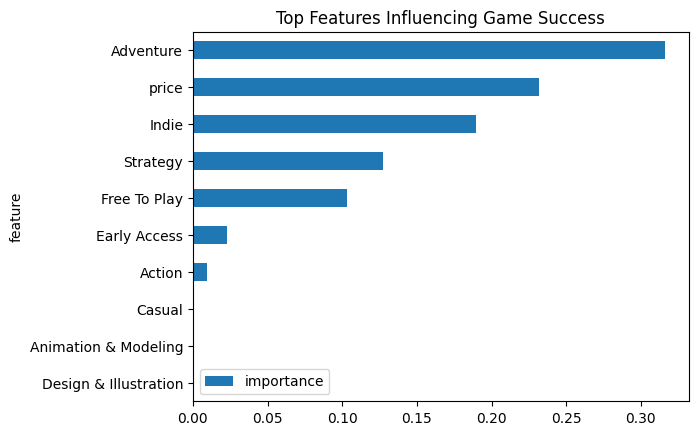

In [13]:
plt.figure()
feat_importance.head(10).plot(
    kind="barh", x="feature", y="importance"
)
plt.title("Top Features Influencing Game Success")
plt.gca().invert_yaxis()
plt.show()

In [16]:
sample = X.iloc[0:1]
prediction = model.predict(sample)

print(sample)
print("Predicted success score:", prediction[0])

   price  Action  Adventure  Animation & Modeling  Casual  \
0    0.0       1          0                     0       0   

   Design & Illustration  Early Access  Free To Play  Indie  \
0                      0             0             1      0   

   Massively Multiplayer  Photo Editing  Strategy  Utilities  
0                      0              0         0          0  
Predicted success score: 0.8616394015398683


In [15]:
import joblib
joblib.dump(model, "success_model.pkl")

['success_model.pkl']

In [18]:
from google.cloud import storage

storage_client = storage.Client()

bucket_name = "rcalp-model-storage"
source_file = "success_model.pkl"
destination_blob = "models/success_model_v1.pkl"

bucket = storage_client.bucket(bucket_name)
blob = bucket.blob(destination_blob)

blob.upload_from_filename(source_file)

print(f"Uploaded to gs://{bucket_name}/{destination_blob}")

Uploaded to gs://rcalp-model-storage/models/success_model_v1.pkl
